# 🍎 Fruit Recognition với Mạng CNN
### Tuần 3 – Machine Learning Assessment

**Mục tiêu:**
- Xây dựng, cấu hình kiến trúc và huấn luyện thành công một mô hình CNN chạy hoàn chỉnh
- Lập ma trận nhầm lẫn (confusion matrix) để đánh giá chi tiết các lỗi phân loại
- Thực hiện trực quan hóa kết quả dự đoán (predict visualization) trên tập test

**Dataset:** `Fruits Classification` – 5 lớp trái cây (Apple, Banana, Grape, Mango, Strawberry),
đã chia sẵn 3 tập `train` / `valid` / `test`.

## 1. Import thư viện

In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Cấu hình & Tải dữ liệu

Cấu trúc thư mục dataset:
```
Fruits Classification/
  train/   Apple/ Banana/ Grape/ Mango/ Strawberry/
  valid/   Apple/ Banana/ Grape/ Mango/ Strawberry/
  test/    Apple/ Banana/ Grape/ Mango/ Strawberry/
```

In [6]:
# ── Cấu hình chung ──────────────────────────────────────────────────────────
BASE_DIR   = 'Fruits Classification'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VALID_DIR  = os.path.join(BASE_DIR, 'valid')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (100, 100)   # kích thước ảnh đầu vào
BATCH_SIZE = 32
EPOCHS     = 30

# Dùng toàn bộ các lớp (None = tất cả)
MAX_CLASSES = None

# ── Chọn tập các lớp ────────────────────────────────────────────────────────
all_classes = sorted(os.listdir(TRAIN_DIR))
selected = all_classes[:MAX_CLASSES] if MAX_CLASSES else all_classes

print(f'Tổng số lớp trong dataset : {len(all_classes)}')
print(f'Số lớp sử dụng            : {len(selected)}')
print(f'Các lớp                   : {selected}')

Tổng số lớp trong dataset : 5
Số lớp sử dụng            : 5
Các lớp                   : ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']


In [7]:
# ── Data Augmentation cho tập Train ─────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale           = 1.0 / 255,
    rotation_range    = 20,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    horizontal_flip   = True,
    zoom_range        = 0.1
)

# Valid / Test chỉ rescale, không augment
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = selected,
    shuffle     = True,
    seed        = SEED
)

val_gen = eval_datagen.flow_from_directory(
    VALID_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = selected,
    shuffle     = False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = selected,
    shuffle     = False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nSố lớp : {NUM_CLASSES} | Mapping: {train_gen.class_indices}')

Found 9700 images belonging to 5 classes.
Found 200 images belonging to 5 classes.
Found 100 images belonging to 5 classes.

Số lớp : 5 | Mapping: {'Apple': 0, 'Banana': 1, 'Grape': 2, 'Mango': 3, 'Strawberry': 4}


## 3. Khám phá dữ liệu (EDA)

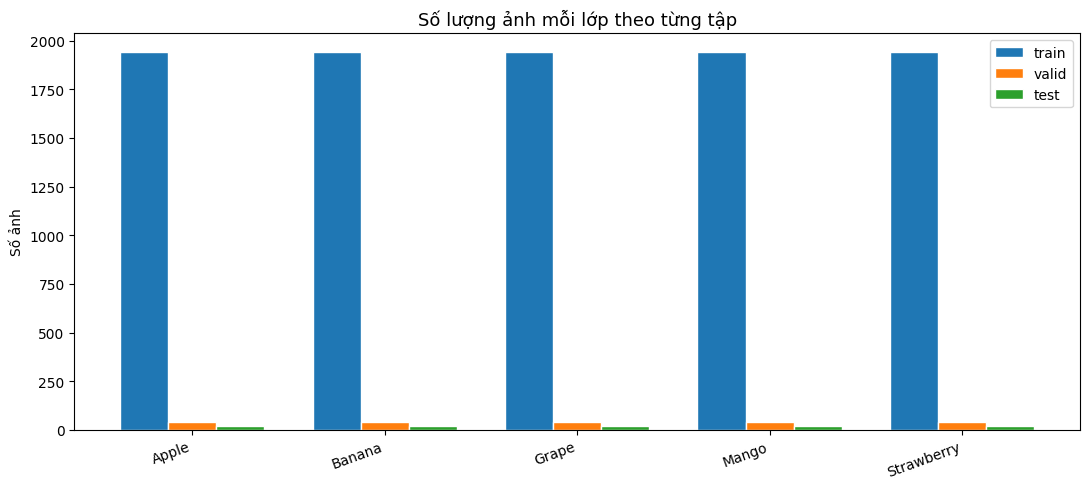

train : tổng 9700 ảnh | {'Apple': 1940, 'Banana': 1940, 'Grape': 1940, 'Mango': 1940, 'Strawberry': 1940}
valid : tổng 200 ảnh | {'Apple': 40, 'Banana': 40, 'Grape': 40, 'Mango': 40, 'Strawberry': 40}
test  : tổng 100 ảnh | {'Apple': 20, 'Banana': 20, 'Grape': 20, 'Mango': 20, 'Strawberry': 20}


In [8]:
# Đếm số ảnh mỗi lớp trong 3 tập
splits = {'train': TRAIN_DIR, 'valid': VALID_DIR, 'test': TEST_DIR}
counts = {s: [len(os.listdir(os.path.join(d, c))) for c in selected]
          for s, d in splits.items()}

x = np.arange(len(selected))
w = 0.25
plt.figure(figsize=(11, 5))
for i, (s, vals) in enumerate(counts.items()):
    plt.bar(x + i * w, vals, w, label=s, edgecolor='white')
plt.xticks(x + w, selected, rotation=20, ha='right')
plt.title('Số lượng ảnh mỗi lớp theo từng tập', fontsize=13)
plt.ylabel('Số ảnh'); plt.legend()
plt.tight_layout(); plt.show()

for s, vals in counts.items():
    print(f'{s:6s}: tổng {sum(vals)} ảnh | {dict(zip(selected, vals))}')

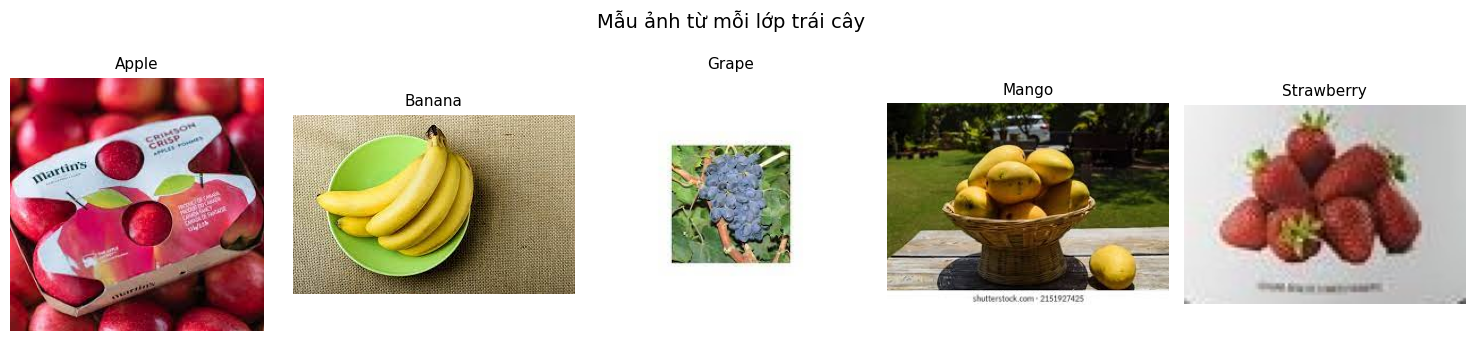

In [9]:
# Hiển thị mẫu ảnh từ mỗi lớp
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 3.2))
if NUM_CLASSES == 1:
    axes = [axes]

for ax, cls in zip(axes, selected):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(cls_dir))
    img = plt.imread(os.path.join(cls_dir, img_file))
    ax.imshow(img)
    ax.set_title(cls, fontsize=11)
    ax.axis('off')

plt.suptitle('Mẫu ảnh từ mỗi lớp trái cây', fontsize=14, y=1.05)
plt.tight_layout(); plt.show()

## 4. Xây dựng kiến trúc CNN

In [10]:
def build_cnn(input_shape, num_classes):
    """
    Kiến trúc CNN gồm 3 khối Conv-BN-Pool + 2 lớp Dense.
    BatchNormalization ổn định huấn luyện; Dropout ngăn overfitting.
    """
    model = models.Sequential(name='FruitCNN')
    model.add(layers.Input(shape=input_shape))

    # ── Khối 1 ──
    model.add(layers.Conv2D(32, (3, 3), padding='same', name='conv1_1'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3, 3), padding='same', name='conv1_2'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Khối 2 ──
    model.add(layers.Conv2D(64, (3, 3), padding='same', name='conv2_1'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3, 3), padding='same', name='conv2_2'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Khối 3 ──
    model.add(layers.Conv2D(128, (3, 3), padding='same', name='conv3_1'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3, 3), padding='same', name='conv3_2'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    # ── Fully-Connected ──
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu', name='fc1'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model


model = build_cnn(IMG_SIZE + (3,), NUM_CLASSES)
model.summary()

Model: "FruitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 25, 25, 128)    │             

 Total params: 5,009,957 (19.11 MB)

 Trainable params: 5,008,549 (19.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 5. Biên dịch & Huấn luyện mô hình

In [11]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_fruit_cnn.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = val_gen,
    callbacks       = callbacks
)

Epoch 1/30
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4079 - loss: 1.6050
Epoch 1: val_accuracy improved from None to 0.49000, saving model to best_fruit_cnn.keras

Epoch 1: finished saving model to best_fruit_cnn.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.4626 - loss: 1.3744 - val_accuracy: 0.4900 - val_loss: 1.3117 - learning_rate: 0.0010
Epoch 2/30
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5638 - loss: 1.1064
Epoch 2: val_accuracy improved from 0.49000 to 0.52000, saving model to best_fruit_cnn.keras

Epoch 2: finished saving model to best_fruit_cnn.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 40s 132ms/step - accuracy: 0.5656 - loss: 1.0931 - val_accuracy: 0.5200 - val_loss: 1.2752 - learning_rate: 0.0010
Epoch 3/30
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5946 - loss: 1.0041
Epoch 3: val_accuracy improved from 0.52000 to 0.55000, saving model to best_fruit_cnn.keras

Epoch 3: finished saving model to best_fruit_cnn.keras
304/

## 6. Biểu đồ Loss & Accuracy qua các epoch

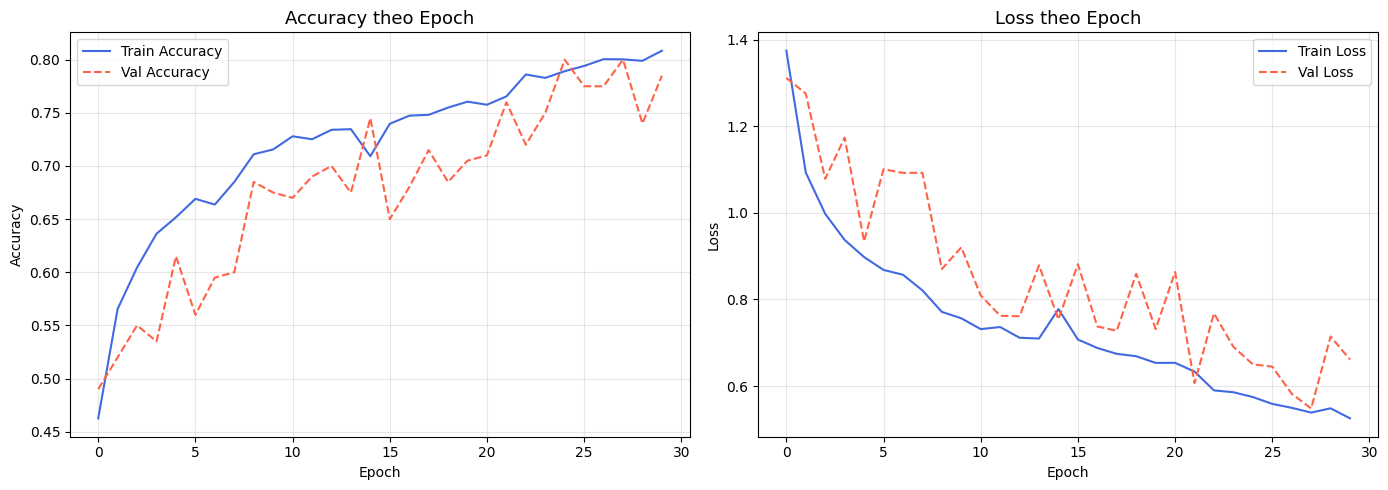

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
axes[0].set_title('Accuracy theo Epoch', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
axes[1].set_title('Loss theo Epoch', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 7. Đánh giá trên tập Test

In [13]:
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.8500 - loss: 0.4938

Test Loss     : 0.4938
Test Accuracy : 0.8500  (85.00%)


## 8. Ma trận nhầm lẫn (Confusion Matrix)

In [14]:
# Lấy nhãn thật và nhãn dự đoán từ tập test
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes          # nhãn thật (index)

cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix shape:', cm.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step
Confusion matrix shape: (5, 5)


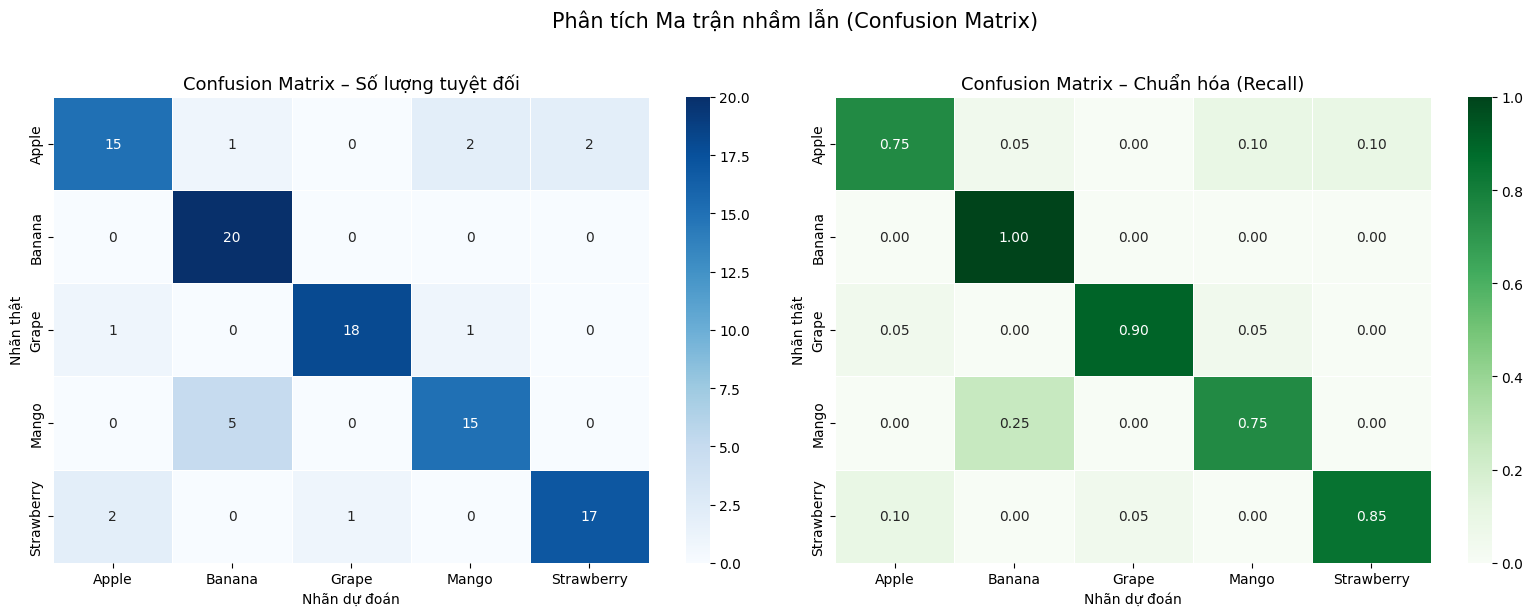

In [15]:
# ── Vẽ Confusion Matrix ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Giá trị tuyệt đối
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix – Số lượng tuyệt đối', fontsize=13)
axes[0].set_xlabel('Nhãn dự đoán'); axes[0].set_ylabel('Nhãn thật')

# (b) Chuẩn hóa theo hàng (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix – Chuẩn hóa (Recall)', fontsize=13)
axes[1].set_xlabel('Nhãn dự đoán'); axes[1].set_ylabel('Nhãn thật')

plt.suptitle('Phân tích Ma trận nhầm lẫn (Confusion Matrix)', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

In [16]:
# ── Báo cáo phân loại chi tiết ──────────────────────────────────────────────
print('=' * 60)
print('Classification Report')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Classification Report
              precision    recall  f1-score   support

       Apple       0.83      0.75      0.79        20
      Banana       0.77      1.00      0.87        20
       Grape       0.95      0.90      0.92        20
       Mango       0.83      0.75      0.79        20
  Strawberry       0.89      0.85      0.87        20

    accuracy                           0.85       100
   macro avg       0.86      0.85      0.85       100
weighted avg       0.86      0.85      0.85       100



In [17]:
# ── Các cặp lớp bị nhầm lẫn nhiều nhất ───────────────────────────────────────
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
errors = [(CLASS_NAMES[i], CLASS_NAMES[j], cm_no_diag[i, j])
          for i in range(NUM_CLASSES) for j in range(NUM_CLASSES)
          if cm_no_diag[i, j] > 0]
errors.sort(key=lambda x: -x[2])

print('Top nhầm lẫn nhiều nhất:')
print(f'{"Thật":<15} {"Dự đoán":<15} {"Số lần nhầm"}')
print('-' * 45)
for true_cls, pred_cls, cnt in errors[:10]:
    print(f'{true_cls:<15} {pred_cls:<15} {int(cnt)}')
if not errors:
    print('Không có lỗi phân loại nào! 🎉')

Top nhầm lẫn nhiều nhất:
Thật            Dự đoán         Số lần nhầm
---------------------------------------------
Mango           Banana          5
Apple           Mango           2
Apple           Strawberry      2
Strawberry      Apple           2
Apple           Banana          1
Grape           Apple           1
Grape           Mango           1
Strawberry      Grape           1


## 9. Trực quan hóa kết quả dự đoán (Predict Visualization)

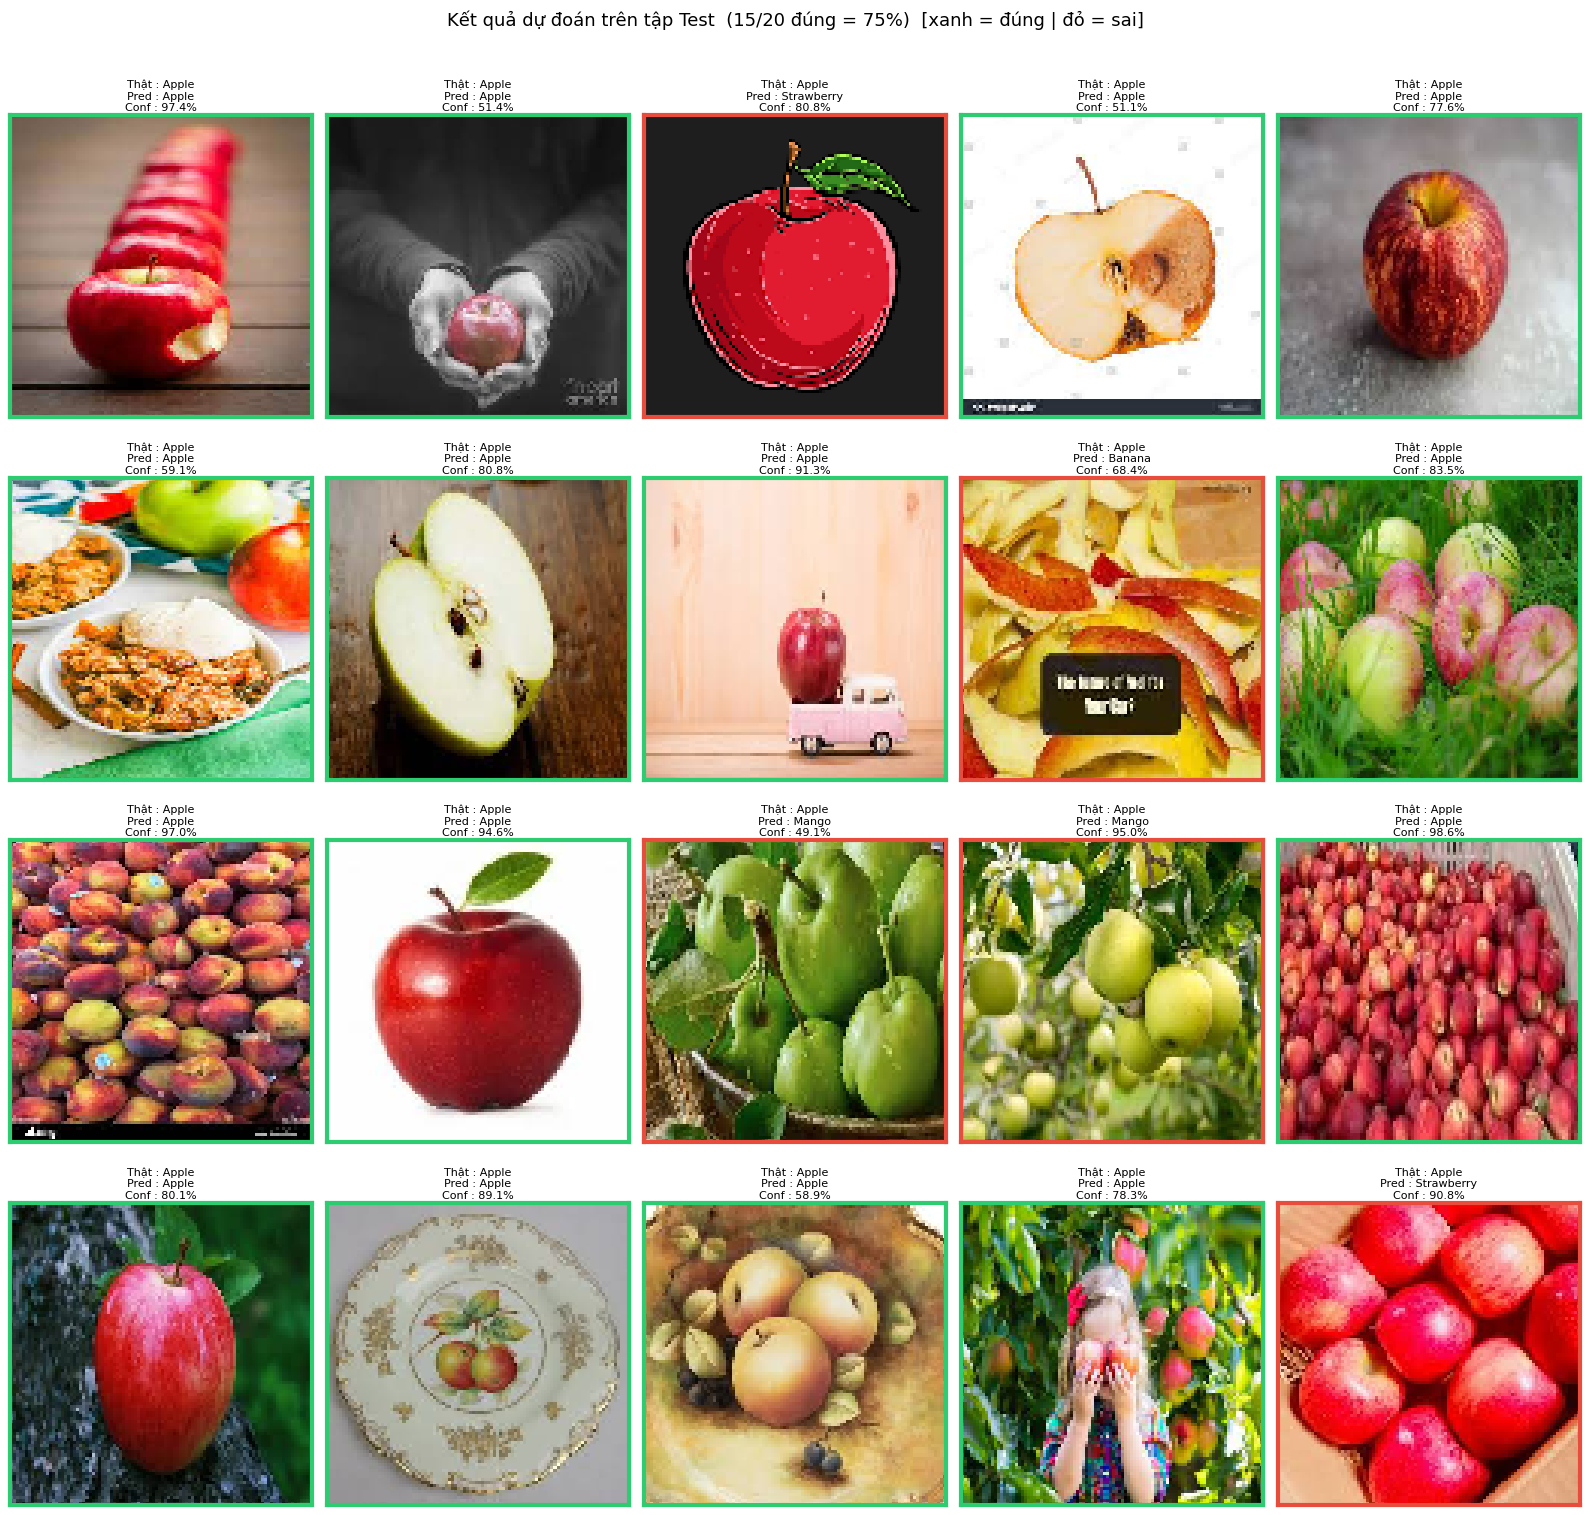

In [18]:
def visualize_predictions(generator, model, class_names, n=20, cols=5):
    """
    Hiển thị n ảnh kèm nhãn thật & dự đoán.
    Khung xanh = đúng, đỏ = sai.
    """
    generator.reset()
    images, labels = [], []
    while len(images) < n:
        imgs, lbls = next(generator)
        images.extend(imgs)
        labels.extend(np.argmax(lbls, axis=1))

    images = np.array(images[:n])
    labels = np.array(labels[:n])

    preds_prob = model.predict(images, verbose=0)
    preds = np.argmax(preds_prob, axis=1)
    confs = np.max(preds_prob, axis=1)

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.8))
    axes = np.array(axes).flatten()

    for i in range(n):
        axes[i].imshow(images[i])
        correct = (preds[i] == labels[i])
        color = '#2ecc71' if correct else '#e74c3c'
        axes[i].set_title(
            f'Thật : {class_names[labels[i]]}\n'
            f'Pred : {class_names[preds[i]]}\n'
            f'Conf : {confs[i]*100:.1f}%',
            fontsize=8, pad=3)
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        axes[i].set_xticks([]); axes[i].set_yticks([])

    for j in range(n, len(axes)):
        axes[j].axis('off')

    correct_count = int(np.sum(preds == labels))
    plt.suptitle(
        f'Kết quả dự đoán trên tập Test  '
        f'({correct_count}/{n} đúng = {correct_count/n*100:.0f}%)  '
        f'[xanh = đúng | đỏ = sai]',
        fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()


visualize_predictions(test_gen, model, CLASS_NAMES, n=20, cols=5)

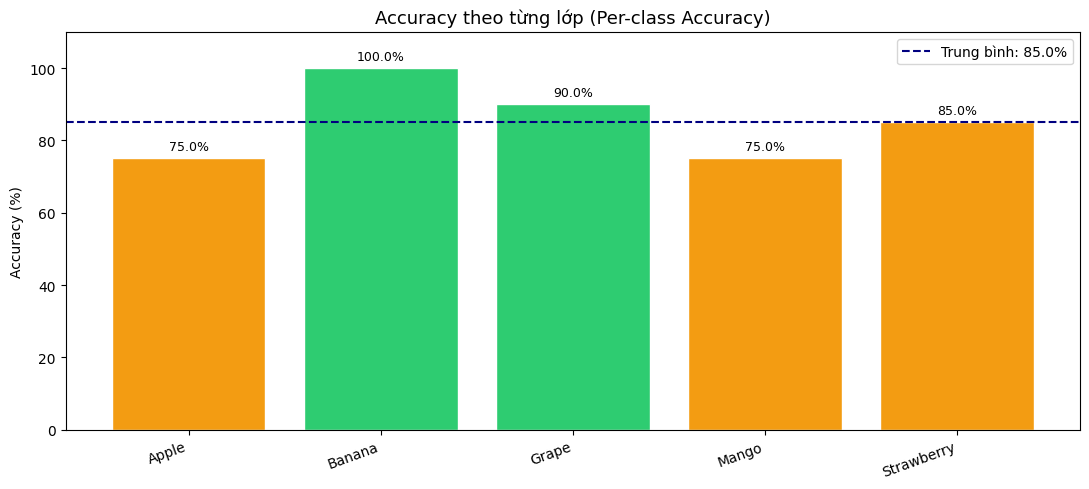

In [19]:
# ── Per-class accuracy ──────────────────────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = ['#2ecc71' if a >= 0.9 else ('#f39c12' if a >= 0.7 else '#e74c3c')
          for a in per_class_acc]

plt.figure(figsize=(11, 5))
bars = plt.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white')
plt.axhline(np.mean(per_class_acc) * 100, color='navy', linestyle='--',
            label=f'Trung bình: {np.mean(per_class_acc)*100:.1f}%')
plt.xticks(rotation=20, ha='right')
plt.ylabel('Accuracy (%)'); plt.ylim(0, 110)
plt.title('Accuracy theo từng lớp (Per-class Accuracy)', fontsize=13)
plt.legend()
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## 10. Trực quan hóa Feature Maps (tùy chọn)

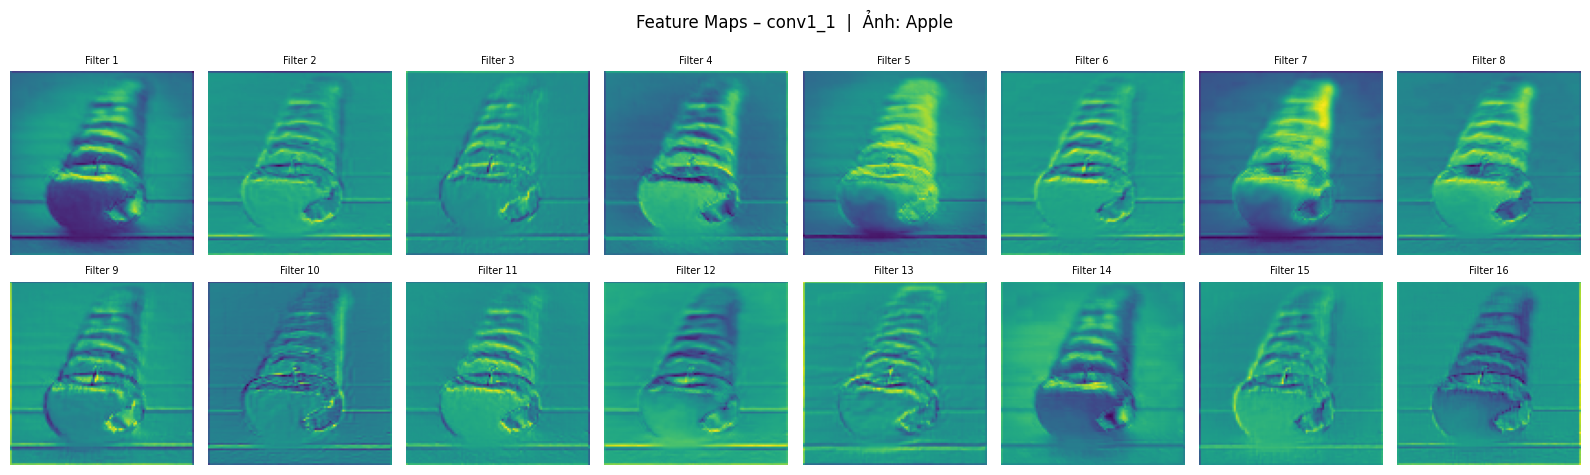

In [20]:
# Lấy một ảnh mẫu từ tập test
test_gen.reset()
sample_imgs, sample_lbls = next(test_gen)
sample_img   = sample_imgs[0:1]
sample_label = CLASS_NAMES[np.argmax(sample_lbls[0])]

# Sub-model xuất feature maps của lớp Conv đầu tiên
activation_model = models.Model(inputs=model.inputs,
                                outputs=model.get_layer('conv1_1').output)
fmaps = activation_model.predict(sample_img, verbose=0)[0]

n_filters = min(16, fmaps.shape[-1])
fig, axes = plt.subplots(2, n_filters // 2, figsize=(n_filters, 5))
axes = axes.flatten()
for i in range(n_filters):
    axes[i].imshow(fmaps[:, :, i], cmap='viridis')
    axes[i].set_title(f'Filter {i+1}', fontsize=7)
    axes[i].axis('off')
plt.suptitle(f'Feature Maps – conv1_1  |  Ảnh: {sample_label}', fontsize=12)
plt.tight_layout(); plt.show()

## 11. Tóm tắt kết quả

In [21]:
print('=' * 55)
print('         KẾT QUẢ TỔNG HỢP – FRUIT CNN')
print('=' * 55)
print(f'  Số lớp huấn luyện   : {NUM_CLASSES}')
print(f'  Kích thước ảnh      : {IMG_SIZE}')
print(f'  Epochs (thực tế)    : {len(history.history["loss"])}')
print(f'  Test Accuracy       : {test_acc*100:.2f}%')
print(f'  Test Loss           : {test_loss:.4f}')
print(f'  Per-class Acc TB    : {np.mean(per_class_acc)*100:.2f}%')
print(f'  Lớp tốt nhất        : {CLASS_NAMES[np.argmax(per_class_acc)]} ({np.max(per_class_acc)*100:.1f}%)')
print(f'  Lớp kém nhất        : {CLASS_NAMES[np.argmin(per_class_acc)]} ({np.min(per_class_acc)*100:.1f}%)')
print('=' * 55)

         KẾT QUẢ TỔNG HỢP – FRUIT CNN
  Số lớp huấn luyện   : 5
  Kích thước ảnh      : (100, 100)
  Epochs (thực tế)    : 30
  Test Accuracy       : 85.00%
  Test Loss           : 0.4938
  Per-class Acc TB    : 85.00%
  Lớp tốt nhất        : Banana (100.0%)
  Lớp kém nhất        : Apple (75.0%)
